# **1. Perkenalan Dataset**

Dataset yang digunakan pada eksperimen ini adalah **House Prices - Advanced Regression Techniques** yang bersumber dari [Kaggle](https://www.kaggle.com/c/house-prices-advanced-regression-techniques).

**Informasi Dataset:**
- Jumlah baris: 1460
- Jumlah kolom: 81 (termasuk target)
- Target/label: `SalePrice` (harga jual rumah, regresi)
- Fitur terdiri dari kombinasi data numerik (luas tanah, jumlah kamar, tahun dibangun, dll) dan data kategorikal (kualitas material, tipe garasi, zonasi, dll)
- File yang digunakan: `namadataset_raw/train.csv`
- Deskripsi lengkap setiap kolom dapat dilihat pada `namadataset_raw/data_description.txt`

**Tujuan eksperimen:** memahami karakteristik dataset melalui EDA, kemudian melakukan data preprocessing agar dataset siap digunakan untuk pelatihan model Machine Learning regresi (memprediksi `SalePrice`).

# **2. Import Library**

Pustaka yang digunakan: `pandas` dan `numpy` untuk manipulasi data, `matplotlib` dan `seaborn` untuk visualisasi, serta `scikit-learn` untuk preprocessing (encoding, scaling, train-test split).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


# **3. Memuat Dataset**

Dataset dimuat dari file CSV `namadataset_raw/train.csv`. Beberapa baris awal dan informasi struktur data ditampilkan untuk memastikan dataset berhasil dimuat dengan benar.

In [2]:
RAW_PATH = "namadataset_raw/train.csv"

df = pd.read_csv(RAW_PATH)
print("Shape:", df.shape)
df.head()


Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini dilakukan eksplorasi terhadap distribusi target, nilai yang hilang (missing values), tipe data, korelasi antar fitur numerik, serta hubungan beberapa fitur penting dengan target `SalePrice`.

In [4]:
# Statistik deskriptif kolom numerik
df.describe()


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


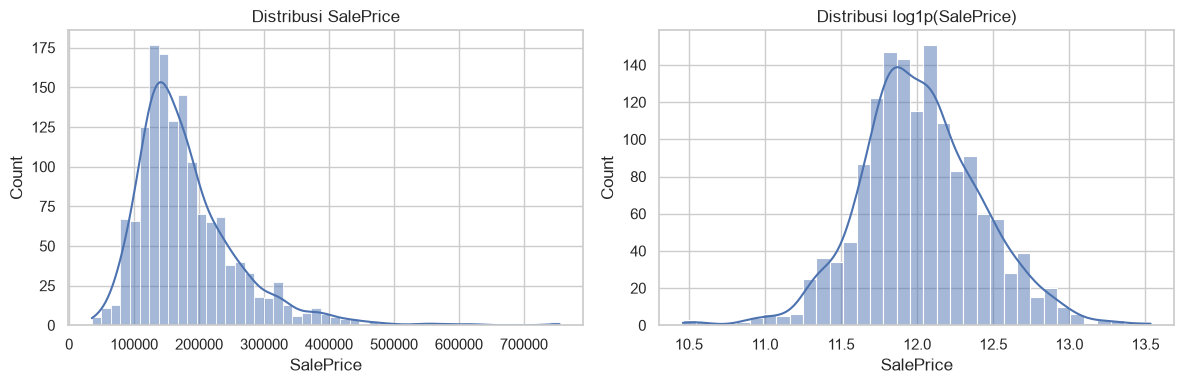

In [5]:
# Distribusi target SalePrice
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title("Distribusi SalePrice")

sns.histplot(np.log1p(df["SalePrice"]), kde=True, ax=axes[1])
axes[1].set_title("Distribusi log1p(SalePrice)")
plt.tight_layout()
plt.show()


In [6]:
# Kolom dengan missing values terbanyak
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})


,missing_count,missing_pct
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


In [7]:
# Korelasi fitur numerik terhadap SalePrice (top 10)
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()["SalePrice"].sort_values(ascending=False)
corr.head(11)


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

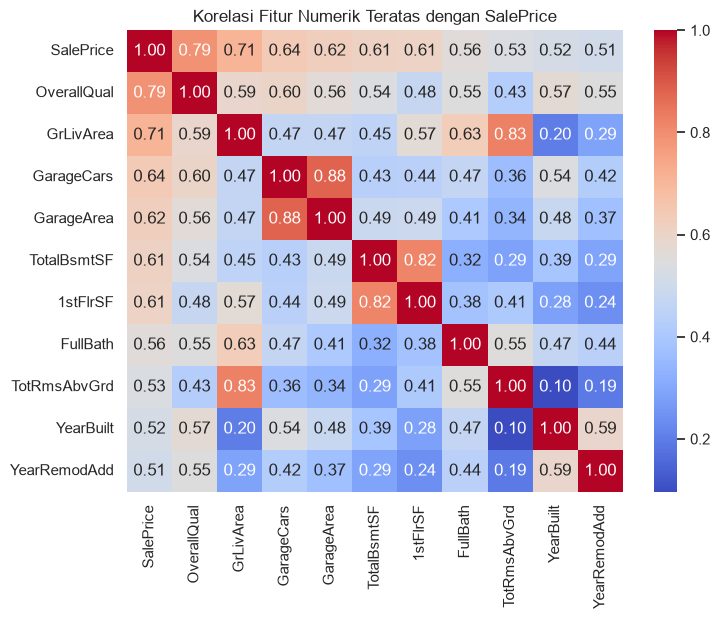

In [8]:
# Heatmap korelasi untuk fitur numerik dengan korelasi tertinggi terhadap SalePrice
top_corr_features = corr.head(11).index
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df[top_corr_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korelasi Fitur Numerik Teratas dengan SalePrice")
plt.show()


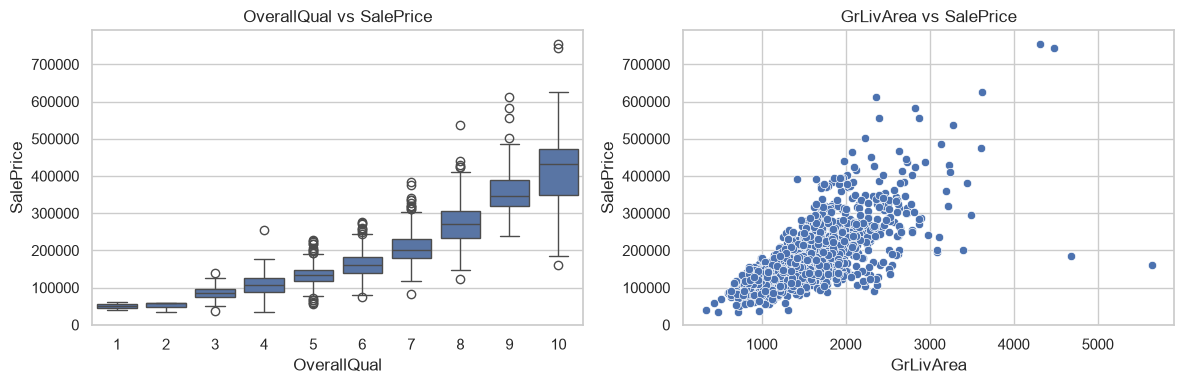

In [9]:
# Hubungan OverallQual dan GrLivArea dengan SalePrice
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x="OverallQual", y="SalePrice", data=df, ax=axes[0])
axes[0].set_title("OverallQual vs SalePrice")

sns.scatterplot(x="GrLivArea", y="SalePrice", data=df, ax=axes[1])
axes[1].set_title("GrLivArea vs SalePrice")
plt.tight_layout()
plt.show()


In [10]:
# Jumlah fitur kategorikal vs numerik
cat_cols = df.select_dtypes(include="object").columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"Jumlah fitur kategorikal: {len(cat_cols)}")
print(f"Jumlah fitur numerik: {len(num_cols)}")


Jumlah fitur kategorikal: 43
Jumlah fitur numerik: 38


C:\Users\Alwan Fauzi\AppData\Local\Temp\ipykernel_29136\2909250639.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


# **5. Data Preprocessing**

Berdasarkan hasil EDA, dilakukan tahapan preprocessing berikut:

1. **Menghapus kolom `Id`** karena tidak relevan untuk pemodelan.
2. **Menangani missing values**:
   - Fitur kategorikal yang NA berarti "tidak memiliki fasilitas tersebut" (misal `Alley`, `BsmtQual`, `GarageType`, `PoolQC`, dll) diisi dengan `"None"`.
   - Fitur numerik terkait (misal `MasVnrArea`, `GarageYrBlt`, `TotalBsmtSF`) diisi dengan `0`.
   - `LotFrontage` diisi dengan median.
   - `Electrical` diisi dengan modus.
3. **Transformasi target**: `SalePrice` di-log-transform (`log1p`) agar distribusinya lebih mendekati normal.
4. **Encoding fitur kategorikal** menggunakan One-Hot Encoding.
5. **Scaling fitur numerik** menggunakan `StandardScaler`.
6. **Split data** menjadi train (80%) dan test (20%).

Seluruh logika ini dibungkus dalam fungsi-fungsi pada `automate_Alwan-Fauzi.py` agar dapat digunakan kembali (reusable) dan dijalankan otomatis melalui GitHub Actions.

In [11]:
import importlib.util

# Memuat fungsi preprocessing dari automate_Alwan-Fauzi.py (nama file mengandung tanda hubung
# sehingga tidak bisa di-import langsung dengan `import`)
spec = importlib.util.spec_from_file_location("automate_alwan_fauzi", "automate_Alwan-Fauzi.py")
automate_alwan_fauzi = importlib.util.module_from_spec(spec)
spec.loader.exec_module(automate_alwan_fauzi)
preprocess_data = automate_alwan_fauzi.preprocess_data

OUTPUT_DIR = "namadataset_preprocessing"

train_df, test_df = preprocess_data(
    input_path=RAW_PATH,
    output_dir=OUTPUT_DIR,
    test_size=0.2,
    random_state=42,
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()


Train shape: (1168, 260)
Test shape: (292, 260)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_None,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_NoSeWa,...,FireplaceQu_Gd,FireplaceQu_None,FireplaceQu_Po,FireplaceQu_TA,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Fa,GarageQual_Gd,GarageQual_None,GarageQual_Po,GarageQual_TA,GarageCond_Fa,GarageCond_Gd,GarageCond_None,GarageCond_Po,GarageCond_TA,PavedDrive_P,PavedDrive_Y,PoolQC_Fa,PoolQC_Gd,PoolQC_None,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_None,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,SalePrice
254,-0.866764,-0.004193,-0.212896,-0.820445,0.372217,-0.455469,-1.346063,-0.597889,1.037269,-0.285504,-0.400282,0.572612,0.374235,-0.801923,-0.118999,-0.407093,1.105320,-0.24287,-1.055566,-0.764098,0.136218,-0.212757,-0.964566,-0.958592,0.192392,-1.056544,-0.863837,1.188402,-0.714352,-0.351921,-0.121008,-0.275838,-0.070993,-0.09274,-0.133417,1.650065,False,False,True,False,True,True,False,False,False,True,False,False,True,False,...,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,11.884496
1066,0.074110,-0.493958,-0.265245,-0.088934,1.268609,0.718609,0.439214,-0.597889,-0.971996,-0.285504,0.511920,-0.596547,-0.958202,0.955088,-0.118999,0.083170,-0.818694,-0.24287,0.773664,1.236947,0.136218,-0.212757,0.270755,0.592150,0.272225,0.295092,-0.456264,-0.740157,-0.138015,-0.351921,-0.121008,-0.275838,-0.070993,-0.09274,-0.508010,0.893677,False,False,True,False,True,True,False,False,False,False,False,False,True,False,...,False,False,False,True,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,12.089544
638,-0.631546,-0.137765,-0.177841,-0.820445,1.268609,-1.988293,-1.683818,-0.597889,-0.971996,-0.285504,0.505196,-0.603357,-0.965964,-0.801923,-0.118999,-1.395250,-0.818694,-0.24287,-1.055566,-0.764098,-1.106774,-0.212757,-1.582227,-0.958592,-4.147410,-2.408179,-2.257169,1.790113,-0.714352,2.290826,-0.121008,-0.275838,-0.070993,-0.09274,-0.508010,0.137290,False,False,True,False,True,True,False,False,False,True,False,False,True,False,...,False,True,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,11.350418
799,-0.161109,-0.449434,-0.324474,-0.820445,1.268609,-1.107734,-1.683818,0.861522,0.267995,-0.285504,-0.915776,-0.750921,-0.487321,0.989227,-0.118999,0.458975,1.105320,-0.24287,-1.055566,1.236947,0.136218,-0.212757,0.270755,2.142892,0.152476,-1.056544,-1.119755,-0.740157,-0.714352,3.902257,-0.121008,-0.275838,-0.070993,-0.09274,-0.133417,-0.619098,False,False,True,False,True,True,False,False,False,True,False,False,True,False,...,False,False,False,True,False,Fals

In [12]:
# Validasi: tidak ada missing value pada hasil preprocessing
print("Missing values (train):", train_df.isnull().sum().sum())
print("Missing values (test):", test_df.isnull().sum().sum())
print("\nFile hasil preprocessing tersimpan di folder:", OUTPUT_DIR)
os.listdir(OUTPUT_DIR)


Missing values (train): 0
Missing values (test): 0

File hasil preprocessing tersimpan di folder: namadataset_preprocessing


['test_preprocessed.csv', 'train_preprocessed.csv']